# Prédiction du WMI — Pipeline de classification supervisée

**Objectif :** prédire la catégorie du *Working Memory Index* (WMI) — `bad` / `medium` / `good` —
à partir de variables neurophysiologiques et anatomiques (potentiels évoqués, latences, volumes...).

**Plan du notebook :**
1. Préprocessing (chargement, split, encodage, nettoyage, discrétisation, ACP exploratoire)
2. Modélisation — comparaison de plusieurs classifieurs
3. Modèles complémentaires (One-vs-Rest, arbre de décision) et analyse des résidus


# 1. Préprocessing

## 1.1 Imports

On importe :
- `pandas` / `numpy` pour la manipulation de données ;
- `seaborn` / `matplotlib` pour les visualisations ;
- `scikit-learn` pour le split train/test, la validation croisée, la recherche d'hyperparamètres
  (`GridSearchCV`), l'encodage, l'imputation, la standardisation et la réduction de dimension (PCA).


In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.model_selection import (
    train_test_split, StratifiedKFold, GridSearchCV, learning_curve,
)
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.impute import KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.decomposition import PCA

pd.set_option("display.precision", 3)

## 1.2 Chargement des données

Lecture du fichier Excel source (feuille `Total2`). Les différentes graphies de valeurs
manquantes rencontrées dans le fichier (`na`, `NaN`, `N/A`, ...) sont explicitement listées
pour être toutes reconnues comme `NaN` par pandas.


In [2]:
filepath = r"C:\Users\melan\DESU_DATA_2026\ProjetNR\data2026.xlsx"
raw_df = pd.read_excel(filepath, engine="openpyxl", sheet_name='Total2', header=0,
                       na_values=['na', 'NaN', 'NA', 'N/A', 'n/a', 'nan'])
raw_df.head()
raw_df.shape

(65, 18)

## 1.3 Split train / test — AVANT tout prétraitement

**Utilité :** en séparant train et test *avant* toute étape de nettoyage/encodage/imputation, on
garantit qu'aucune information du test (y compris la cible) ne peut influencer un choix fait sur
le train. C'est la condition de base pour obtenir, à la fin, une estimation honnête de la
performance du modèle sur des données jamais vues.

On sépare donc `X` (les 8 prédicteurs) de `y` (la cible `WMI`), puis on effectue le split
(90% train / 10% test).


In [3]:
TARGET_COLUMN = "WMI"
PREDICTOR_COLUMNS = ["P300", "P600", "LNC", "N400", "LRC", "OB", "ON", "Hipp"]

X = raw_df[PREDICTOR_COLUMNS].copy()
y = raw_df[TARGET_COLUMN].copy()

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)

print(f"Cible : {TARGET_COLUMN}")
print(f"Train : {X_train.shape[0]} patients | Test : {X_test.shape[0]} patients")

Cible : WMI
Train : 58 patients | Test : 7 patients


## 1.4 Encodage de la variable catégorielle `Hipp`

**Méthode utilisée : `OneHotEncoder`.** Elle transforme une variable catégorielle (ex. un statut
hippocampique) en plusieurs colonnes binaires (0/1), une par catégorie, ce qui est indispensable
pour la plupart des modèles de `scikit-learn` qui n'acceptent que des variables numériques.

**Utilité de fit/transform séparés :** l'encodeur est **fit uniquement sur `X_train`** puis
seulement **appliqué** (`transform`) sur `X_test`, avec `handle_unknown="ignore"` pour ignorer
sans erreur une catégorie rare qui n'apparaîtrait que dans le test. Cela évite que la composition
du test influence la définition des catégories.


In [4]:
def encode_hipp(df, encoder, fit=False):
    df = df.copy()
    if fit:
        encoded = encoder.fit_transform(df[["Hipp"]])
    else:
        encoded = encoder.transform(df[["Hipp"]])
    hipp_columns = encoder.get_feature_names_out(["Hipp"])
    encoded_df = pd.DataFrame(encoded, columns=hipp_columns, index=df.index)
    return pd.concat([df.drop(columns=["Hipp"]), encoded_df], axis=1)

hipp_encoder = OneHotEncoder(sparse_output=False, handle_unknown="ignore")

X_train = encode_hipp(X_train, hipp_encoder, fit=True)
X_test = encode_hipp(X_test, hipp_encoder, fit=False)

X_train.head()

,P300,P600,LNC,N400,LRC,OB,ON,Hipp_NI,Hipp_ZE,Hipp_ZP
12,-125.3,92.5,-21.6,-54.0,11.2,NaN,NaN,1.0,0.0,0.0
64,-48.4,33.7,-53.2,NaN,NaN,NaN,NaN,0.0,0.0,1.0
30,0.0,113.2,-73.1,NaN,NaN,1,81/81,0.0,0.0,1.0
33,0.0,168.0,-74.2,-11.0,0.0,98%,80/77,0.0,1.0,0.0
9,-105.0,79.3,-18.8,NaN,NaN,0.94,68/43,1.0,0.0,0.0


## 1.5 Nettoyage des données : suppression des colonnes trop incomplètes

**Utilité :** une colonne avec trop de valeurs manquantes apporte peu d'information et complique
l'imputation ; on la supprime plutôt que de risquer d'imputer des valeurs peu fiables.

Le seuil de suppression est calculé **uniquement sur `X_train`**, puis la même liste de colonnes
est retirée de `X_test` — on ne regarde jamais les valeurs du test pour décider quoi supprimer.


### 1.5.1 Taux de valeurs manquantes par variable (train)

In [5]:
percent_missing = X_train.isnull().sum() * 100 / len(X_train)
percent_missing.sort_values(ascending=False, inplace=True)
percent_missing

ON         60.345
OB         58.621
LRC        36.207
N400       36.207
P600        3.448
P300        3.448
LNC         3.448
Hipp_NI     0.000
Hipp_ZE     0.000
Hipp_ZP     0.000
dtype: float64

### 1.5.2 Visualisation

Barplot des variables dont le taux de valeurs manquantes dépasse `threshold_view` (10%), avec une
ligne verticale marquant le seuil de suppression retenu (`threshold` = 40%).


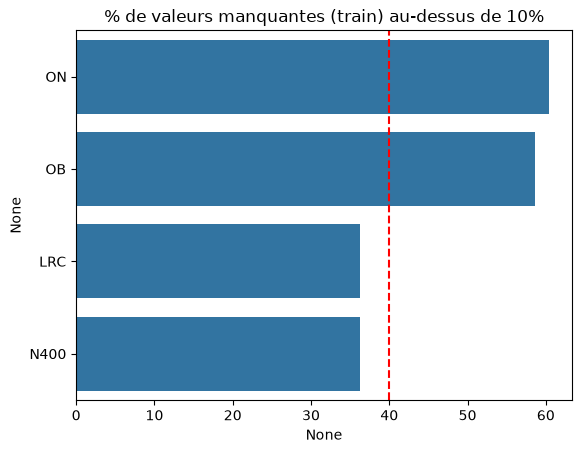

In [6]:
threshold_view = 10
filtered = percent_missing[percent_missing.values > threshold_view]

threshold = 40
if len(filtered) > 0:
    ax = sns.barplot(x=filtered, y=filtered.index, orient='h')
    ax.set_title(f"% de valeurs manquantes (train) au-dessus de {threshold_view}%")
    ax.axvline(x=threshold, color='r', linestyle='--', label=f"Seuil de {threshold}")
else:
    print("Aucune colonne au-dessus du seuil d'affichage.")

### 1.5.3 Suppression effective des colonnes au-dessus du seuil

In [7]:
columns_to_drop = percent_missing[percent_missing.values > threshold].index

X_train = X_train.drop(columns=columns_to_drop, errors="ignore")
X_test = X_test.drop(columns=columns_to_drop, errors="ignore")

print(f"Colonnes supprimées (> {threshold}% manquant sur le train) : {list(columns_to_drop)}")
X_train.shape, X_test.shape

Colonnes supprimées (> 40% manquant sur le train) : ['ON', 'OB']


((58, 8), (7, 8))

## 1.6 Retrait des lignes où la cible (`WMI`) est manquante

**Utilité :** on n'impute jamais la variable à prédire — il est impossible d'entraîner ou
d'évaluer un modèle sur une ligne dont on ne connaît pas la vraie réponse. On filtre donc
train et test séparément, chacun sur son propre masque de valeurs manquantes.


In [8]:
train_mask = y_train.notna()
test_mask = y_test.notna()

print(f"Lignes retirées (train, {TARGET_COLUMN} manquant) : {(~train_mask).sum()}")
print(f"Lignes retirées (test, {TARGET_COLUMN} manquant)  : {(~test_mask).sum()}")

X_train = X_train.loc[train_mask.index[train_mask]]
y_train = y_train.loc[train_mask]

X_test = X_test.loc[test_mask]
y_test = y_test.loc[test_mask]

print(f"Train final : {X_train.shape[0]} patients | Test final : {X_test.shape[0]} patients")

Lignes retirées (train, WMI manquant) : 2
Lignes retirées (test, WMI manquant)  : 0
Train final : 56 patients | Test final : 7 patients


## 1.7 Visualisation exploratoire : WMI en fonction de chaque variable (train)

**Utilité :** un simple nuage de points de la cible contre chaque prédicteur permet de repérer
visuellement d'éventuelles relations (linéaires ou non), des valeurs aberrantes, ou l'absence
totale de lien — une étape rapide avant de se lancer dans la modélisation.


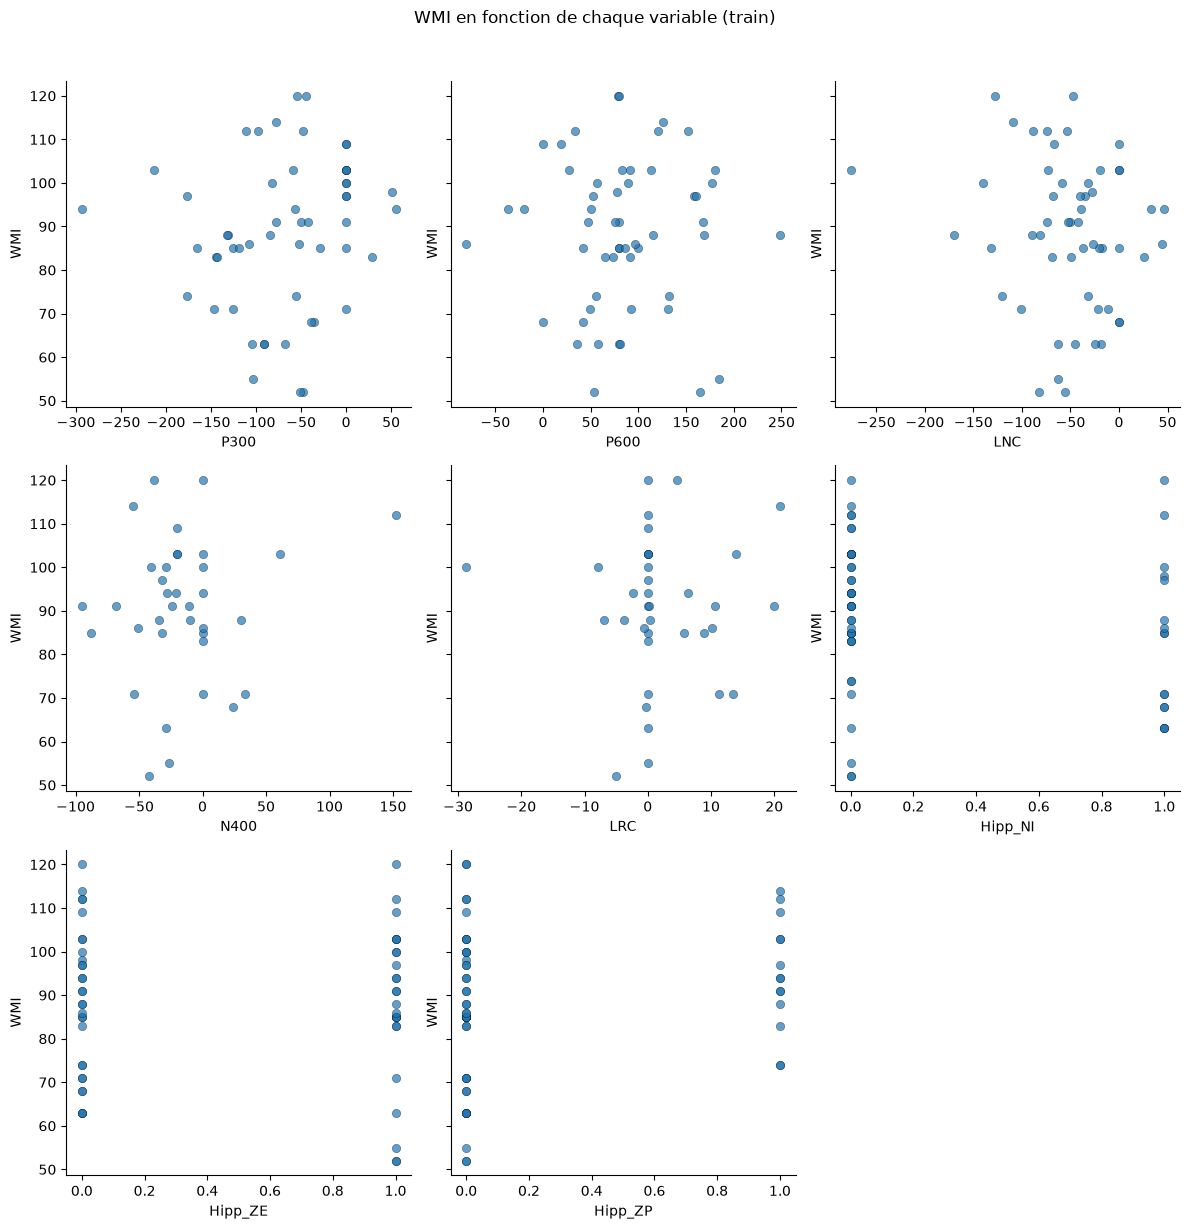

In [9]:
n_cols = 3
n_rows = int(np.ceil(len(X_train.columns) / n_cols))

fig, axes = plt.subplots(n_rows, n_cols, figsize=(4 * n_cols, 4 * n_rows), sharey=True)
axes = axes.flatten()

for ax, feature in zip(axes, X_train.columns):
    ax.scatter(X_train[feature], y_train, alpha=0.7, edgecolor="k", linewidth=0.3)
    ax.set_xlabel(feature)
    ax.set_ylabel("WMI")
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

for ax in axes[len(X_train.columns):]:
    ax.axis("off")

fig.suptitle("WMI en fonction de chaque variable (train)", y=1.02)
plt.tight_layout()
plt.show()

## 1.8 Discrétisation de la cible WMI

**Utilité :** WMI est ici une variable continue. On la transforme en une variable catégorielle à
3 classes (`bad`, `medium`, `good`) via des **terciles**, ce qui permet de reformuler le problème
en une tâche de **classification** (plus robuste ici qu'une régression, notamment avec un
échantillon de petite taille) et facilite l'interprétation clinique du résultat.

Les bornes des terciles sont calculées **uniquement sur `y_train`**, puis appliquées telles
quelles à `y_test` (pas de recalcul sur le test, pour éviter toute fuite d'information).


In [10]:
# y_train / y_test sont des Series (colonne WMI) : on les convertit en DataFrame
y_train_df = y_train.to_frame(name="WMI")
y_test_df = y_test.to_frame(name="WMI")

# Bornes calculées UNIQUEMENT sur le train (jamais sur le test, pour éviter une fuite)
bin_edges = [
    y_train_df["WMI"].min() - 1,
    y_train_df["WMI"].quantile(1 / 3),
    y_train_df["WMI"].quantile(2 / 3),
    y_train_df["WMI"].max() + 1,
]
labels = ["bad", "medium", "good"]

y_train_df["WMI_Category"] = pd.cut(x=y_train_df["WMI"], bins=bin_edges, labels=labels)

# On applique les mêmes bornes au test (pas de recalcul sur le test !)
y_test_df["WMI_Category"] = pd.cut(x=y_test_df["WMI"], bins=bin_edges, labels=labels)

## 1.9 Réduction de dimension : Analyse en Composantes Principales (ACP)

**Utilité de la PCA :** avec seulement 8 prédicteurs (potentiellement corrélés) pour un
échantillon de petite taille, réduire la dimension permet de limiter le risque de surapprentissage
et d'accélérer l'entraînement, tout en conservant l'essentiel de l'information (variance).

Cette PCA exploratoire sert uniquement à **choisir un nombre de composantes raisonnable** ; la
PCA "officielle" utilisée dans les pipelines de modélisation ci-dessous est re-fit indépendamment
à chaque pli de validation croisée (donc jamais sur les données du pli de validation).

`X_train` contient encore des valeurs manquantes à ce stade : un `KNNImputer` est utilisé pour
imputer temporairement les valeurs manquantes en s'appuyant sur les k plus proches voisins,
uniquement dans le but de pouvoir fitter cette PCA exploratoire.


### 1.9.1 Éboulis des valeurs propres

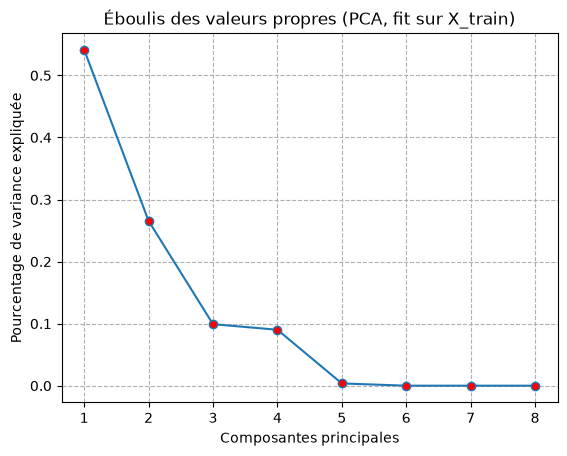

In [12]:
X_train_imputed_for_pca = KNNImputer().fit_transform(X_train)

pca_explore = PCA()
pca_explore.fit(X_train_imputed_for_pca)

explained_variance_ratio = pca_explore.explained_variance_ratio_

plt.plot(
    range(1, len(explained_variance_ratio) + 1),
    explained_variance_ratio,
    marker="o",
    markerfacecolor="r",
)
plt.xlabel("Composantes principales")
plt.xticks(range(1, len(explained_variance_ratio) + 1))
plt.ylabel("Pourcentage de variance expliquée")
plt.grid(linestyle="--")
plt.title("Éboulis des valeurs propres (PCA, fit sur X_train)")
plt.show()

### 1.9.2 Choix du nombre de composantes

On retient le plus petit nombre de composantes permettant d'expliquer au moins **90%** de la
variance totale — un compromis classique entre compression de l'information et perte de
signal.


In [13]:
cumulative_variance = np.cumsum(explained_variance_ratio)
n_components = int(np.argmax(cumulative_variance >= 0.90) + 1)

print(f"Variance expliquée cumulée par composante : {np.round(cumulative_variance, 3)}")
print(f"Nombre de composantes retenues pour atteindre 90% de variance : {n_components}")

Variance expliquée cumulée par composante : [0.541 0.807 0.906 0.996 1.    1.    1.    1.   ]
Nombre de composantes retenues pour atteindre 90% de variance : 3


# 2. Modélisation — comparaison de plusieurs classifieurs

**Modèles comparés :** Régression Logistique, Analyse Discriminante Linéaire (LDA), SVM (SVC),
Random Forest, Gradient Boosting. Chaque modèle capture des types de relations différents
(linéaires, à marges maximales, à base d'arbres...), d'où l'intérêt de les comparer sur les
mêmes données plutôt que d'en choisir un a priori.

**Utilité de la `Pipeline` :** le `KNNImputer`, le `StandardScaler` et la `PCA` sont placés dans
la `Pipeline` (et non appliqués une fois pour toutes en amont) afin d'être **re-fit à chaque pli**
de la validation croisée — cela évite toute fuite de données du pli de validation vers le pli
d'entraînement.

Le test (`X_test`, `y_test`) reste intouché jusqu'à l'évaluation finale (section 2.3).

**Utilité du `GridSearchCV` multi-métriques :** chaque `GridSearchCV` est lancé une seule fois
avec plusieurs métriques (`Accuracy`, `F1_macro`, `Balanced_accuracy`) ; on récupère toutes les
métriques du meilleur jeu de paramètres directement depuis `cv_results_`, sans relancer une
seconde cross-validation (plus rapide, et cohérence garantie entre les métriques rapportées).


## 2.1 Grille de recherche et validation croisée pour chaque modèle

In [14]:
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
import warnings
warnings.filterwarnings("ignore")

X = X_train
y = y_train_df["WMI_Category"]

# StratifiedKFold : conserve la proportion de chaque classe (bad/medium/good) dans chaque pli, important avec un petit échantillon
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
imputer = KNNImputer()

param_grids = {

    "Logistic Regression": (
        LogisticRegression(max_iter=10000),
        {
            "model__C": [0.01, 0.1, 1, 10],
            "model__penalty": ["l2"],
        },
    ),

    "LDA": (
        LinearDiscriminantAnalysis(),
        {
            "model__solver": ["svd", "lsqr"],
        },
    ),

    "SVC": (
        SVC(),
        {
            "model__C": [0.1, 1, 10],
            "model__gamma": ["scale", "auto"],
            "model__kernel": ["rbf", "linear"],
        },
    ),

    "Random Forest": (
        RandomForestClassifier(random_state=42),
        {
            "model__n_estimators": [100, 300],
            "model__max_depth": [None, 3, 5],
            "model__min_samples_leaf": [1, 2, 4],
        },
    ),

    "Gradient Boosting": (
        GradientBoostingClassifier(random_state=42),
        {
            "model__n_estimators": [100, 200],
            "model__max_depth": [2, 3],
            "model__learning_rate": [0.01, 0.1],
        },
    ),
}

scoring = {
    "Accuracy": "accuracy",
    "F1_macro": "f1_macro",
    "Balanced_accuracy": "balanced_accuracy",
}

models = {}
results = []

for name, (estimator, grid) in param_grids.items():

    pipeline = Pipeline([
        ("imputer", imputer),
        ("scaler", StandardScaler()),
        ("pca", PCA(n_components=n_components)),
        ("model", estimator),
    ])

    grid_search = GridSearchCV(
        pipeline,
        param_grid=grid,
        scoring=scoring,
        refit="F1_macro",  # le modèle final est re-fit sur tout le train avec les meilleurs hyperparamètres 
        cv=cv,
        n_jobs=1,
    )

    grid_search.fit(X, y)

    # on conserve le pipeline complet
    models[name] = grid_search.best_estimator_

    best_idx = grid_search.best_index_
    cvres = grid_search.cv_results_

    results.append({
        "Model": name,
        "Accuracy_mean": cvres["mean_test_Accuracy"][best_idx],
        "F1_macro_mean": cvres["mean_test_F1_macro"][best_idx],
        "Balanced_accuracy_mean": cvres["mean_test_Balanced_accuracy"][best_idx],
        "Best params": grid_search.best_params_,
    })

    print(
        f"{name} : meilleurs paramètres = "
        f"{grid_search.best_params_} "
        f"(F1_macro = {cvres['mean_test_F1_macro'][best_idx]:.3f})"
    )

results_df = (
    pd.DataFrame(results)
    .sort_values("Accuracy_mean", ascending=False)
    .reset_index(drop=True)
)

display(results_df)

Logistic Regression : meilleurs paramètres = {'model__C': 0.1, 'model__penalty': 'l2'} (F1_macro = 0.321)
LDA : meilleurs paramètres = {'model__solver': 'lsqr'} (F1_macro = 0.308)
SVC : meilleurs paramètres = {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'} (F1_macro = 0.321)
Random Forest : meilleurs paramètres = {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 300} (F1_macro = 0.309)
Gradient Boosting : meilleurs paramètres = {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 200} (F1_macro = 0.289)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,Random Forest,0.412,0.309,0.366,"{'model__max_depth': 3, 'model__min_samples_le..."
1,Logistic Regression,0.394,0.321,0.361,"{'model__C': 0.1, 'model__penalty': 'l2'}"
2,SVC,0.392,0.321,0.358,"{'model__C': 10, 'model__gamma': 'scale', 'mod..."
3,LDA,0.376,0.308,0.353,{'model__solver': 'lsqr'}
4,Gradient Boosting,0.356,0.289,0.322,"{'model__learning_rate': 0.1, 'model__max_dept..."


## 2.2 Visualisation comparative des modèles

Comparaison de l'accuracy moyenne (validation croisée, train uniquement) entre modèles, avec une
ligne de référence correspondant à un classifieur aléatoire pour 3 classes équilibrées (1/3).
Les barres vertes signalent les modèles au-dessus du hasard, les rouges les modèles en dessous.


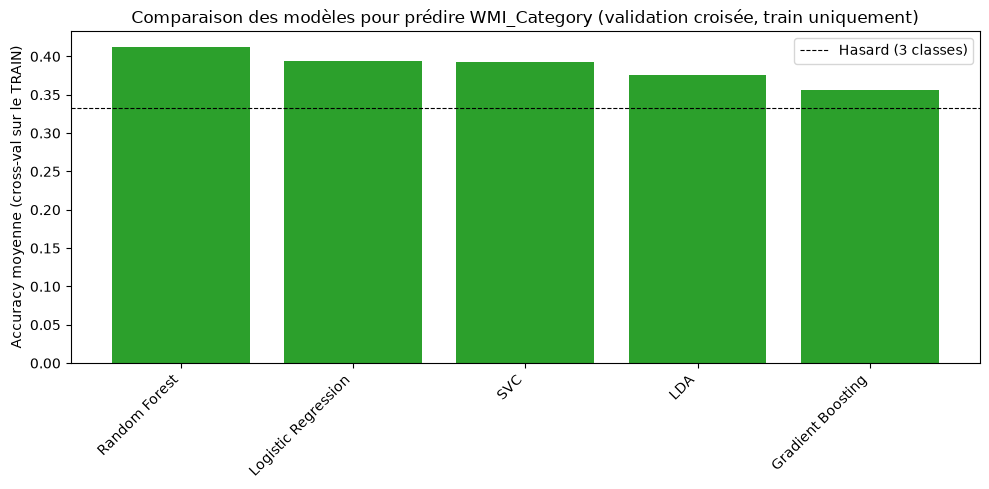

In [15]:
plt.figure(figsize=(10, 5))
colors = ["#2ca02c" if acc >= 1/3 else "#d62728" for acc in results_df["Accuracy_mean"]]
plt.bar(results_df["Model"], results_df["Accuracy_mean"], color=colors)

# Ligne de référence : accuracy d'un classifieur "au hasard" pour 3 classes équilibrées
plt.axhline(1/3, color="black", linewidth=0.8, linestyle="--", label="Hasard (3 classes)")

plt.xticks(rotation=45, ha="right")
plt.ylabel("Accuracy moyenne (cross-val sur le TRAIN)")
plt.title(f"Comparaison des modèles pour prédire {TARGET_COLUMN}_Category (validation croisée, train uniquement)")
plt.legend()
plt.tight_layout()
plt.show()

## 2.3 Sélection du meilleur modèle et évaluation UNIQUE sur le test

**Utilité :** le modèle est choisi selon sa performance en validation croisée **sur le train**
uniquement (pas d'accès au test avant ce stade). Il est ensuite entraîné une seule fois sur
l'intégralité du train, puis évalué **une seule fois** sur le test — la seule métrique qui compte
réellement pour juger la performance hors échantillon, non biaisée par la sélection de modèle.


In [16]:
from sklearn.metrics import accuracy_score, f1_score, balanced_accuracy_score

# Meilleur modèle sélectionné
best_model_name = results_df.iloc[0]["Model"]
final_pipeline = models[best_model_name]

# Données de test
y_test_cat = y_test_df["WMI_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test = pd.DataFrame([{
    "Modèle retenu": best_model_name,
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(results_df.iloc[0]["Accuracy_mean"], 3),
}])

summary_test

,Modèle retenu,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,Random Forest,0.286,0.148,0.222,0.412


## 2.4 Matrices de confusion — train vs test

**Utilité :** la matrice de confusion détaille, classe par classe, où le modèle se trompe (par
exemple, confond-il surtout `medium` avec `bad`, ou avec `good` ?). Comparer train et test permet
aussi de détecter un éventuel surapprentissage (très bonne performance sur le train, nettement
moins bonne sur le test).


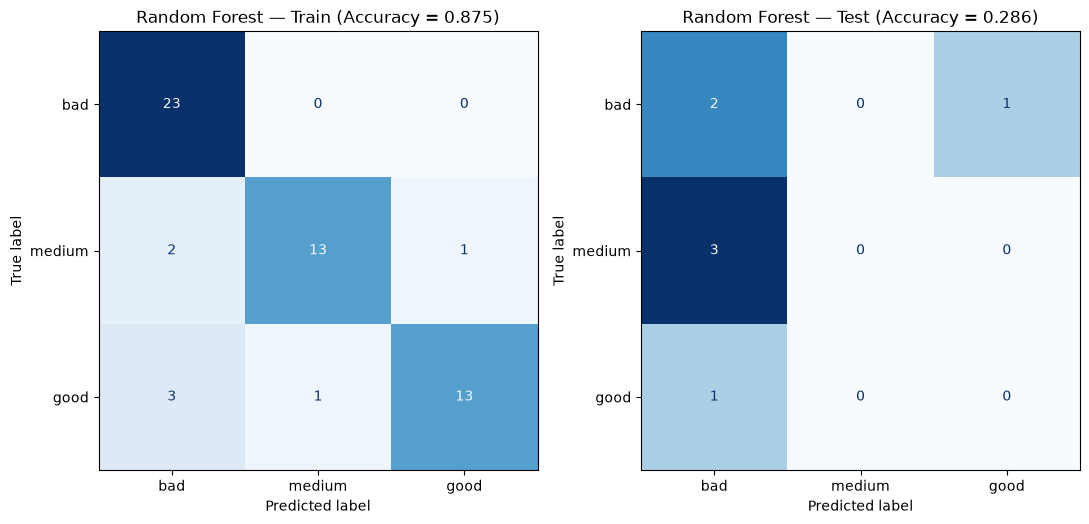

In [17]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_train = final_pipeline.predict(X_train)
train_accuracy = accuracy_score(y, y_pred_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_train,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"{best_model_name} — Train (Accuracy = {train_accuracy:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    y_pred_test,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"{best_model_name} — Test (Accuracy = {test_accuracy:.3f})")

plt.tight_layout()
plt.show()

## 2.5 Learning curve du modèle retenu

**Utilité :** la *learning curve* montre l'évolution de l'accuracy (entraînement et validation
croisée interne au train) en fonction de la taille de l'échantillon d'entraînement. Elle permet
de diagnostiquer si le modèle souffre d'un **manque de données** (les deux courbes ne se
rejoignent pas et continuent de progresser) ou d'un **surapprentissage** (écart persistant entre
train et validation).


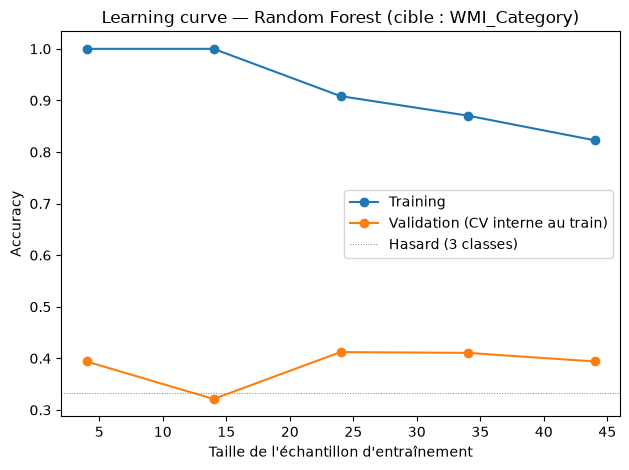

Cible prédite : WMI_Category (bad / medium / good)
Échantillon   : 56 (train) / 7 (test)

Classement des modèles (CV sur le train) :
              Model  Accuracy_mean  F1_macro_mean  Balanced_accuracy_mean                                                                       Best params
      Random Forest          0.412          0.309                   0.366 {'model__max_depth': 3, 'model__min_samples_leaf': 1, 'model__n_estimators': 300}
Logistic Regression          0.394          0.321                   0.361                                         {'model__C': 0.1, 'model__penalty': 'l2'}
                SVC          0.392          0.321                   0.358              {'model__C': 10, 'model__gamma': 'scale', 'model__kernel': 'linear'}
                LDA          0.376          0.308                   0.353                                                         {'model__solver': 'lsqr'}
  Gradient Boosting          0.356          0.289                   0.322  {'model__lea

In [18]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — {best_model_name} (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Classement des modèles (CV sur le train) :")
print(results_df.to_string(index=False))
print()
print("Performance du modèle retenu sur le test (jamais vu avant) :")
print(summary_test.to_string(index=False))

# 3. Modèles complémentaires

Cette section teste, à part du tableau comparatif principal, deux approches supplémentaires :
un `OneVsRestClassifier` (régression logistique) et un arbre de décision (`DecisionTreeClassifier`),
ainsi qu'une analyse des résidus du modèle One-vs-Rest.


## 3.1 One-vs-Rest Classifier

**Utilité de la méthode :** la stratégie *One-vs-Rest* entraîne un classifieur binaire distinct
pour chaque classe (`bad` vs reste, `medium` vs reste, `good` vs reste) puis retient la classe
dont le classifieur est le plus confiant. C'est une alternative à l'approche multinomiale native
de `LogisticRegression`, utile pour comparer les deux façons de gérer un problème multi-classes.


In [19]:
from sklearn.multiclass import OneVsRestClassifier

param_grid_ovr = {
    "model__estimator__C": [0.01, 0.1, 1, 10],
    "model__estimator__penalty": ["l2"],
    "model__estimator__solver": ["lbfgs"],
}

pipeline_ovr = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components)),
    ("model", OneVsRestClassifier(LogisticRegression(max_iter=1000))),
])

grid_search_ovr = GridSearchCV(
    pipeline_ovr,
    param_grid=param_grid_ovr,
    scoring=scoring,
    refit="F1_macro",
    cv=cv,
    n_jobs=1,
)

grid_search_ovr.fit(X, y)

models["OneVsRest"] = grid_search_ovr.best_estimator_

best_idx_ovr = grid_search_ovr.best_index_
cvres_ovr = grid_search_ovr.cv_results_

ovr_cv_summary = {
    "Model": "OneVsRest",
    "Accuracy_mean": cvres_ovr["mean_test_Accuracy"][best_idx_ovr],
    "F1_macro_mean": cvres_ovr["mean_test_F1_macro"][best_idx_ovr],
    "Balanced_accuracy_mean": cvres_ovr["mean_test_Balanced_accuracy"][best_idx_ovr],
    "Best params": grid_search_ovr.best_params_,
}

print(
    f"OneVsRest : meilleurs paramètres = "
    f"{grid_search_ovr.best_params_} "
    f"(F1_macro = {cvres_ovr['mean_test_F1_macro'][best_idx_ovr]:.3f})"
)

pd.DataFrame([ovr_cv_summary])

OneVsRest : meilleurs paramètres = {'model__estimator__C': 0.1, 'model__estimator__penalty': 'l2', 'model__estimator__solver': 'lbfgs'} (F1_macro = 0.309)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,OneVsRest,0.412,0.309,0.369,"{'model__estimator__C': 0.1, 'model__estimator..."


### 3.1.1 Évaluation sur le test

Comme en section 2.3, entraînement sur tout le train puis évaluation unique sur le test. Un
contrôle d'alignement des index (`X_test` vs `y_test_cat`) et une assertion de cohérence entre
la métrique recalculée et celle stockée dans le résumé sont ajoutés à titre de vérification.


In [27]:
final_pipeline = models["OneVsRest"]

# Données de test
y_test_cat = y_test_df["WMI_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

print("X_test.index  :", list(X_test.index))
print("y_test_cat.index :", list(y_test_cat.index))
print("Alignés ?", list(X_test.index) == list(y_test_cat.index))

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)


# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test_ovr = pd.DataFrame([{
    "Modèle": "OneVsRest",
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(ovr_cv_summary["Accuracy_mean"], 3),
}])

print(summary_test_ovr.to_string(index=False))
assert abs(summary_test_ovr["Accuracy (test)"].iloc[0] - test_accuracy) < 1e-9, "Incohérence détectée !"
print("OK, cohérent :", summary_test_ovr["Accuracy (test)"].iloc[0], "vs", test_accuracy)

X_test.index  : [53, 60, 0, 45, 5, 61, 16]
y_test_cat.index : [53, 60, 0, 45, 5, 61, 16]
Alignés ? True
   Modèle  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
OneVsRest              0.0              0.0                       0.0                0.412
OK, cohérent : 0.0 vs 0.0


### 2.1.2 Matrices de confusion — train vs test

**Utilité :** la matrice de confusion détaille, classe par classe, où le modèle se trompe (par
exemple, confond-il surtout `medium` avec `bad`, ou avec `good` ?). Comparer train et test permet
aussi de détecter un éventuel surapprentissage (très bonne performance sur le train, nettement
moins bonne sur le test).


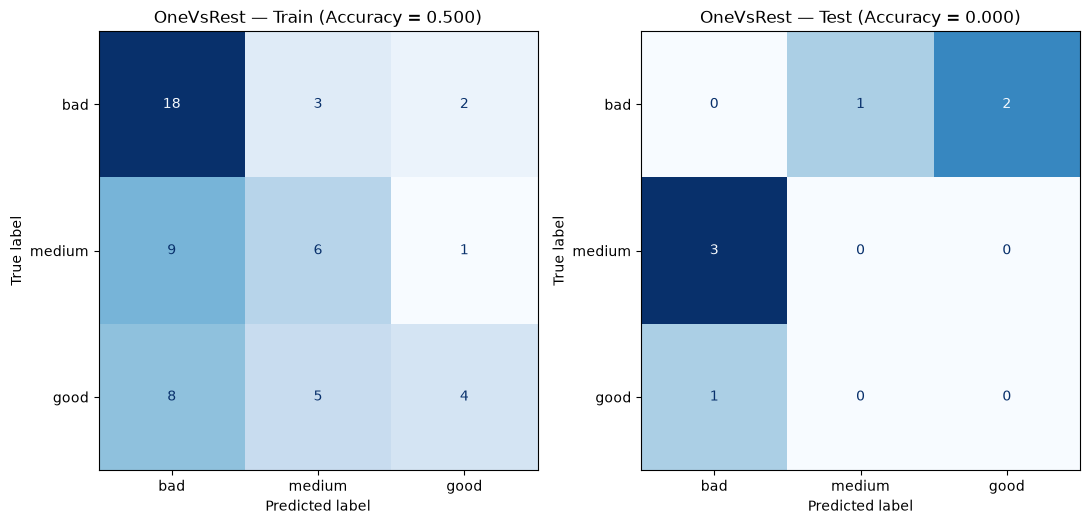

In [29]:
from sklearn.metrics import ConfusionMatrixDisplay

y_pred_train = final_pipeline.predict(X_train)
train_accuracy = accuracy_score(y, y_pred_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_train,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"OneVsRest — Train (Accuracy = {train_accuracy:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    y_pred_test,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"OneVsRest — Test (Accuracy = {test_accuracy:.3f})")

plt.tight_layout()
plt.show()

### 3.1.3 Learning curve — One-vs-Rest

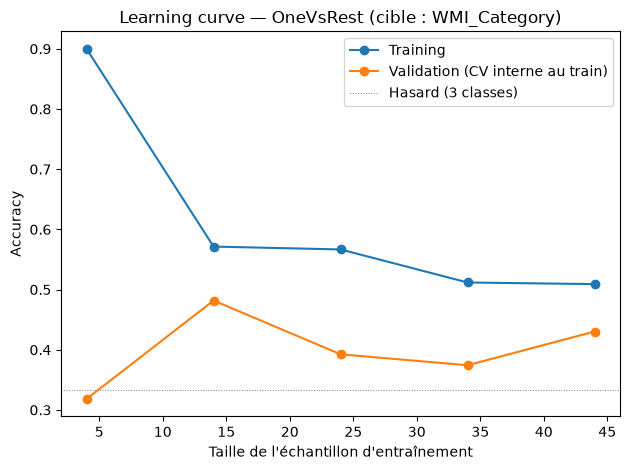

Cible prédite : WMI_Category (bad / medium / good)
Échantillon   : 56 (train) / 7 (test)

Performance du OneVsRestClassifier sur le train (CV interne)
       Model  Accuracy_mean  F1_macro_mean  Balanced_accuracy_mean  \
0  OneVsRest          0.412          0.309                   0.369   

                                         Best params  
0  {'model__estimator__C': 0.1, 'model__estimator...  
Performance du OneVsRestClassifier sur le test (jamais vu avant) :
   Modèle  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
OneVsRest              0.0              0.0                       0.0                0.412


In [22]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — OneVsRest (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Performance du OneVsRestClassifier sur le train (CV interne)")
print(pd.DataFrame([ovr_cv_summary]))
print("Performance du OneVsRestClassifier sur le test (jamais vu avant) :")
print(summary_test_ovr.to_string(index=False))

### 3.2.1 Analyse des résidus (modèle One-vs-Rest)

**Utilité :** bien que la cible soit ici catégorielle, les classes ont un ordre naturel
(`bad` < `medium` < `good`). En les recodant en 0/1/2, on peut calculer des "résidus" numériques
(différence entre catégorie réelle et catégorie prédite) et examiner leur distribution, leur
comportement en fonction des valeurs prédites, et leur normalité (QQ-plot) — un diagnostic
emprunté à la régression, utile ici pour repérer un éventuel biais systématique (le modèle
sous- ou sur-estime-t-il régulièrement la sévérité ?).


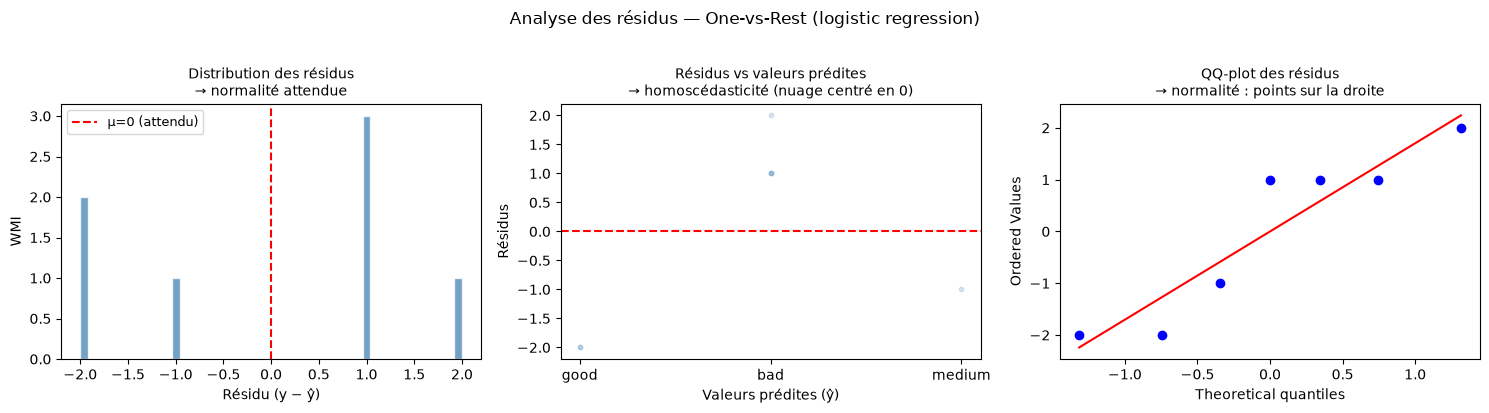

Moyenne des résidus : 0.000  (attendu : ≈ 0)
Médiane des résidus : 1.000


In [23]:
import scipy.stats

category_to_num = {"bad": 0, "medium": 1, "good": 2}

y_true_num = y_test_cat.map(category_to_num).to_numpy()
y_pred_num = pd.Series(y_pred_test, index=y_test_cat.index).map(category_to_num).to_numpy()

residuals = y_true_num - y_pred_num

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# 1. Distribution des résidus
axes[0].hist(residuals, bins=50, color='steelblue', alpha=0.75, edgecolor='white')
axes[0].axvline(0, color='red', linestyle='--', linewidth=1.5, label='μ=0 (attendu)')
axes[0].set_title('Distribution des résidus\n→ normalité attendue', fontsize=10)
axes[0].set_xlabel('Résidu (y − ŷ)')
axes[0].set_ylabel('WMI')
axes[0].legend(fontsize=9)

# 2. Résidus vs valeurs prédites (homoscédasticité)
axes[1].scatter(y_pred_test, residuals, alpha=0.2, color='steelblue', s=10)
axes[1].axhline(0, color='red', linestyle='--', linewidth=1.5)
axes[1].set_title('Résidus vs valeurs prédites\n→ homoscédasticité (nuage centré en 0)', fontsize=10)
axes[1].set_xlabel('Valeurs prédites (ŷ)')
axes[1].set_ylabel('Résidus')

# 3. QQ-plot
scipy.stats.probplot(residuals, dist='norm', plot=axes[2])
axes[2].set_title('QQ-plot des résidus\n→ normalité : points sur la droite', fontsize=10)

plt.suptitle('Analyse des résidus — One-vs-Rest (logistic regression)', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f'Moyenne des résidus : {residuals.mean():.3f}  (attendu : ≈ 0)')
print(f'Médiane des résidus : {np.median(residuals):.3f}')

### 3.2.2 Importance des features

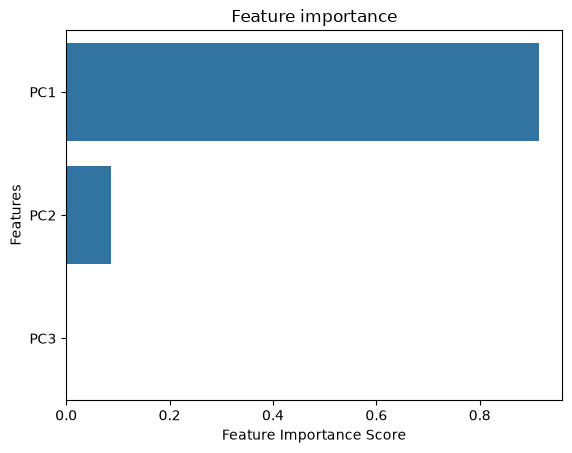

In [35]:
import seaborn as sns
model = final_pipeline.named_steps["model"]
importances = model.feature_importances_

feature_names = [f"PC{i+1}" for i in range(len(importances))]

feature_scores = pd.Series(importances, index=feature_names).sort_values(ascending=False)
sns.barplot(x=feature_scores, y=feature_scores.index)
plt.xlabel('Feature Importance Score')
plt.ylabel('Features')
plt.title("Feature importance")
plt.show()

,PC1,PC2
P300,6.334e-01,7.483e-01
P600,-5.402e-01,6.020e-01
LNC,5.474e-01,-2.756e-01
N400,-8.530e-02,-2.450e-02
LRC,-1.000e-04,-3.350e-02
Hipp_NI,0.000e+00,-5.000e-04
Hipp_ZE,1.000e-04,1.100e-03
Hipp_ZP,-2.000e-04,-5.000e-04


,PC1,PC2
P300,40.12,55.99
P600,29.18,36.24
LNC,29.96,7.59
N400,0.73,0.06
LRC,0.00,0.11
Hipp_NI,0.00,0.00
Hipp_ZE,0.00,0.00
Hipp_ZP,0.00,0.00


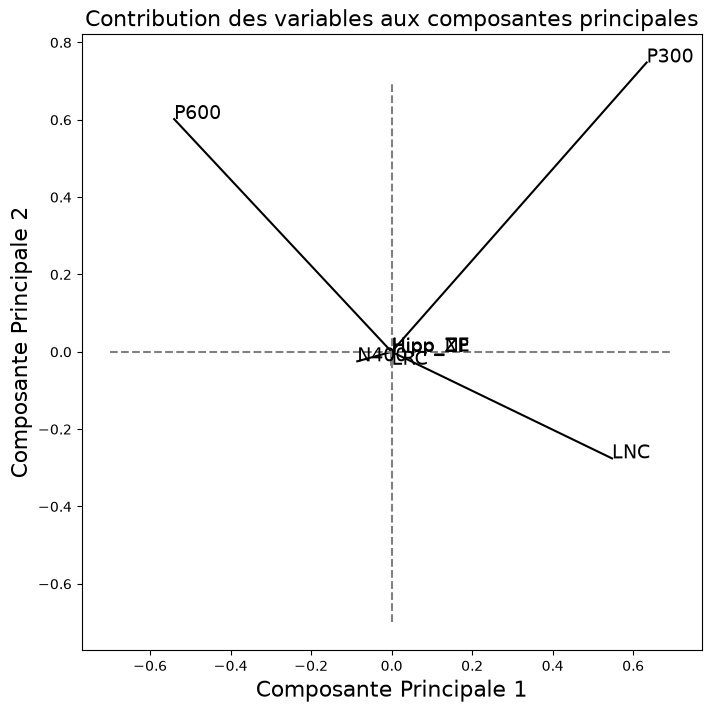

In [40]:
feature_names = X.columns

# Loadings / coordonnées des variables sur PC1 et PC2
pcs = pca_explore.components_[:2, :]   # shape: (2, n_features)

# Tableau des loadings
loadings = pd.DataFrame(
    pcs.T,
    index=feature_names,
    columns=["PC1", "PC2"]
)

# Contributions en % de chaque variable à chaque composante
contrib = (loadings**2).div((loadings**2).sum(axis=0), axis=1) * 100

# Affichage
display(loadings.round(4))
display(contrib.round(2))

# Graphique
fig, ax = plt.subplots(figsize=(8, 8))

for i, (x, y) in enumerate(zip(pcs[0, :], pcs[1, :])):
    ax.plot([0, x], [0, y], color='k')
    ax.text(x, y, feature_names[i], fontsize=14)

ax.plot([-0.7, 0.7], [0, 0], color='grey', ls='--')
ax.plot([0, 0], [-0.7, 0.7], color='grey', ls='--')

ax.set_xlabel("Composante Principale 1", fontsize=16)
ax.set_ylabel("Composante Principale 2", fontsize=16)
ax.set_title("Contribution des variables aux composantes principales", fontsize=16)
plt.show()

## 3.3 Arbre de décision (Decision Tree)

**Utilité de la méthode :** un `DecisionTreeClassifier` segmente l'espace des variables par une
succession de règles simples (seuils sur une variable à la fois). Contrairement aux modèles
linéaires (Régression linéaire, LDA) ou aux modèles "boîte noire" (SVC à noyau, Gradient Boosting), un arbre de
décision unique reste **directement interprétable** (on peut lire les règles de décision), ce qui
est précieux dans un contexte clinique, au prix, généralement, d'une performance et d'une
stabilité moindres qu'un ensemble d'arbres (Random Forest, Gradient Boosting).


In [24]:
from sklearn.tree import DecisionTreeClassifier

param_grid_dt = {
    "model__max_depth": [2, 3, 4, 5, None],
    "model__min_samples_leaf": [1, 2, 4, 8],
    "model__criterion": ["gini", "entropy"],
}

pipeline_dt = Pipeline([
    ("imputer", imputer),
    ("scaler", StandardScaler()),
    ("pca", PCA(n_components=n_components)),
    ("model", DecisionTreeClassifier(random_state=42)),
])

grid_search_dt = GridSearchCV(
    pipeline_dt,
    param_grid=param_grid_dt,
    scoring=scoring,
    refit="F1_macro",
    cv=cv,
    n_jobs=1,
)

grid_search_dt.fit(X, y)

models["Decision Tree"] = grid_search_dt.best_estimator_

best_idx_dt = grid_search_dt.best_index_
cvres_dt = grid_search_dt.cv_results_

dt_cv_summary = {
    "Model": "Decision Tree",
    "Accuracy_mean": cvres_dt["mean_test_Accuracy"][best_idx_dt],
    "F1_macro_mean": cvres_dt["mean_test_F1_macro"][best_idx_dt],
    "Balanced_accuracy_mean": cvres_dt["mean_test_Balanced_accuracy"][best_idx_dt],
    "Best params": grid_search_dt.best_params_,
}

print(
    f"Decision Tree : meilleurs paramètres = "
    f"{grid_search_dt.best_params_} "
    f"(F1_macro = {cvres_dt['mean_test_F1_macro'][best_idx_dt]:.3f})"
)

pd.DataFrame([dt_cv_summary])

Decision Tree : meilleurs paramètres = {'model__criterion': 'gini', 'model__max_depth': 4, 'model__min_samples_leaf': 8} (F1_macro = 0.407)


,Model,Accuracy_mean,F1_macro_mean,Balanced_accuracy_mean,Best params
0,Decision Tree,0.464,0.407,0.448,"{'model__criterion': 'gini', 'model__max_depth..."


### 3.3.1 Évaluation sur le test

In [30]:
final_pipeline = models["Decision Tree"]

# Données de test
y_test_cat = y_test_df["WMI_Category"]

# Entraînement sur tout le train
final_pipeline.fit(X_train, y)

# Prédiction sur le test
y_pred_test = final_pipeline.predict(X_test)

# Métriques
test_accuracy = accuracy_score(y_test_cat, y_pred_test)
test_f1_macro = f1_score(y_test_cat, y_pred_test, average="macro")
test_balanced_accuracy = balanced_accuracy_score(y_test_cat, y_pred_test)

summary_test_dt = pd.DataFrame([{
    "Modèle": "Decision Tree",
    "Accuracy (test)": round(test_accuracy, 3),
    "F1_macro (test)": round(test_f1_macro, 3),
    "Balanced accuracy (test)": round(test_balanced_accuracy, 3),
    "Accuracy CV (train)": round(dt_cv_summary["Accuracy_mean"], 3),
}])

summary_test_dt

,Modèle,Accuracy (test),F1_macro (test),Balanced accuracy (test),Accuracy CV (train)
0,Decision Tree,0.429,0.433,0.556,0.464


### 3.3.2 Matrices de confusion — train vs test

**Utilité :** la matrice de confusion détaille, classe par classe, où le modèle se trompe (par
exemple, confond-il surtout `medium` avec `bad`, ou avec `good` ?). Comparer train et test permet
aussi de détecter un éventuel surapprentissage (très bonne performance sur le train, nettement
moins bonne sur le test).


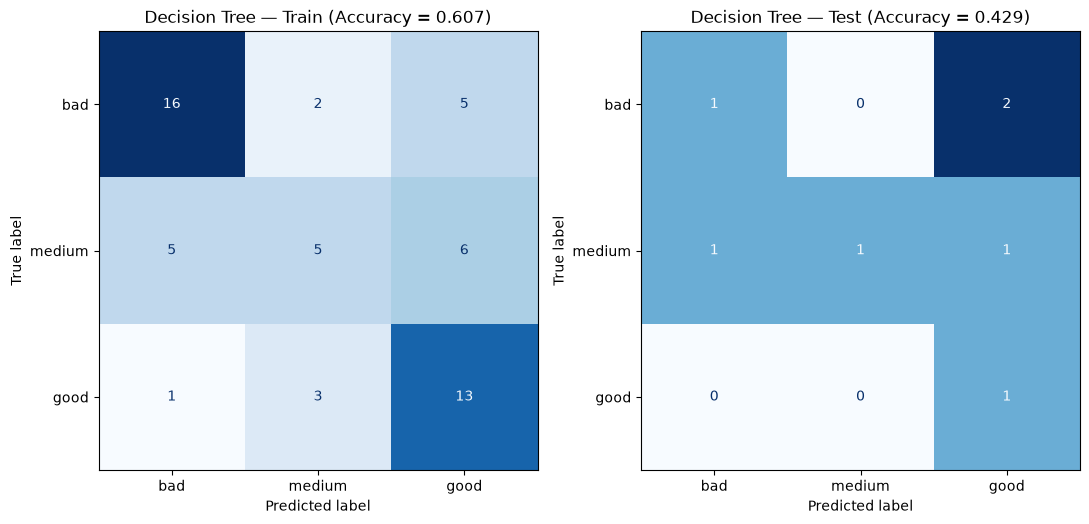

In [31]:
y_pred_train = final_pipeline.predict(X_train)
train_accuracy = accuracy_score(y, y_pred_train)

fig, axes = plt.subplots(1, 2, figsize=(11, 5.5))

ConfusionMatrixDisplay.from_predictions(
    y,
    y_pred_train,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[0],
    colorbar=False,
)
axes[0].set_title(f"Decision Tree — Train (Accuracy = {train_accuracy:.3f})")

ConfusionMatrixDisplay.from_predictions(
    y_test_cat,
    y_pred_test,
    labels=["bad", "medium", "good"],
    cmap="Blues",
    ax=axes[1],
    colorbar=False,
)
axes[1].set_title(f"Decision Tree — Test (Accuracy = {test_accuracy:.3f})")

plt.tight_layout()
plt.show()

### 3.3.3 Learning curve — Decision Tree

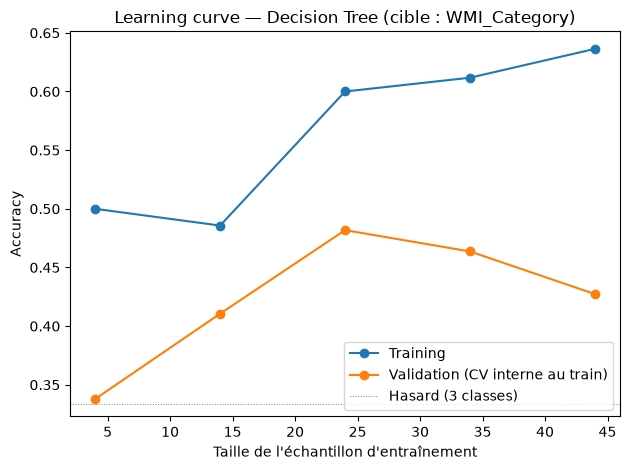

Cible prédite : WMI_Category (bad / medium / good)
Échantillon   : 56 (train) / 7 (test)

Performance du DecisionTreeClassifier sur le test (jamais vu avant) :
       Modèle  Accuracy (test)  F1_macro (test)  Balanced accuracy (test)  Accuracy CV (train)
Decision Tree            0.429            0.433                     0.556                0.464


In [32]:
train_sizes, train_scores, val_scores = learning_curve(
    final_pipeline,
    X,
    y,
    cv=cv,
    scoring="accuracy",
    train_sizes=np.linspace(0.1, 1.0, 5),
)

plt.plot(train_sizes, np.mean(train_scores, axis=1), marker="o", label="Training")
plt.plot(train_sizes, np.mean(val_scores, axis=1), marker="o", label="Validation (CV interne au train)")
plt.axhline(1/3, color="grey", linewidth=0.7, linestyle=":", label="Hasard (3 classes)")
plt.xlabel("Taille de l'échantillon d'entraînement")
plt.ylabel("Accuracy")
plt.title(f"Learning curve — Decision Tree (cible : {TARGET_COLUMN}_Category)")
plt.legend()
plt.tight_layout()
plt.show()

print(f"Cible prédite : {TARGET_COLUMN}_Category (bad / medium / good)")
print(f"Échantillon   : {X.shape[0]} (train) / {X_test.shape[0]} (test)")
print()
print("Performance du DecisionTreeClassifier sur le test (jamais vu avant) :")
print(summary_test_dt.to_string(index=False))